In [75]:
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import json

In [54]:
df = pd.read_json('../data/papers.json')

## Data Exploration

In [55]:
df.head()

,arxiv_id,title,abstract,authors,categories,published,updated,url,pdf_url
0,2605.10938v1,ELF: Embedded Language Flows,Diffusion and flow-based models have become th...,"[Keya Hu, Linlu Qiu, Yiyang Lu, Hanhong Zhao, ...","[cs.CL, cs.AI, cs.LG]",2026-05-11,2026-05-11,http://arxiv.org/abs/2605.10938v1,https://arxiv.org/pdf/2605.10938v1
1,2605.10934v1,Variational Inference for Lévy Process-Driven ...,Modelling extreme events and heavy-tailed phen...,"[Yaman Kindap, Manfred Opper, Benjamin Dupuis,...","[cs.LG, cs.AI, cs.CV, cs.RO, stat.ML]",2026-05-11,2026-05-11,http://arxiv.org/abs/2605.10934v1,https://arxiv.org/pdf/2605.10934v1
2,2605.10933v1,DECO: Sparse Mixture-of-Experts with Dense-Com...,While Mixture-of-Experts (MoE) scales model ca...,"[Chenyang Song, Weilin Zhao, Xu Han, Chaojun X...","[cs.LG, cs.CL]",2026-05-11,2026-05-11,http://arxiv.org/abs/2605.10933v1,https://arxiv.org/pdf/2605.10933v1
3,2605.10931v1,Quantifying Concentration Phenomena of Mean-Fi...,Transformers with self-attention modules as th...,"[Albert Alcalde, Leon Bungert, Konstantin Ried...","[math.AP, cs.LG, math.DS]",2026-05-11,2026-05-11,http://arxiv.org/abs/2605.10931v1,https://arxiv.org/pdf/2605.10931v1
4,2605.10923v1,Dynamic Skill Lifecycle Management for Agentic...,Large language model agents increasingly rely ...,"[Junhao Shen, Teng Zhang, Xiaoyan Zhao, Hong C...","[cs.LG, cs.CL]",2026-05-11,2026-05-11,http://arxiv.org/abs/2605.10923v1,https://arxiv.org/pdf/2605.10923v1


In [56]:
df['categories'].value_counts()

categories
[cs.CV]                                                     249
[cs.CL]                                                     161
[cs.IR]                                                     160
[cs.LG]                                                     145
[cs.AI]                                                     105
                                                           ... 
[cs.CV, cs.NE, q-bio.NC]                                      1
[cs.LG, cs.AI, cs.NE, math.DS, physics.class-ph]              1
[cs.NE, cs.AI, cs.CV, cs.ET]                                  1
[cs.NE, cs.ET, cs.LG]                                         1
[cs.LG, cs.AI, cs.NE, physics.class-ph, physics.comp-ph]      1
Name: count, Length: 634, dtype: int64

<h1>Visualisation</h1>

##  Category Distribution

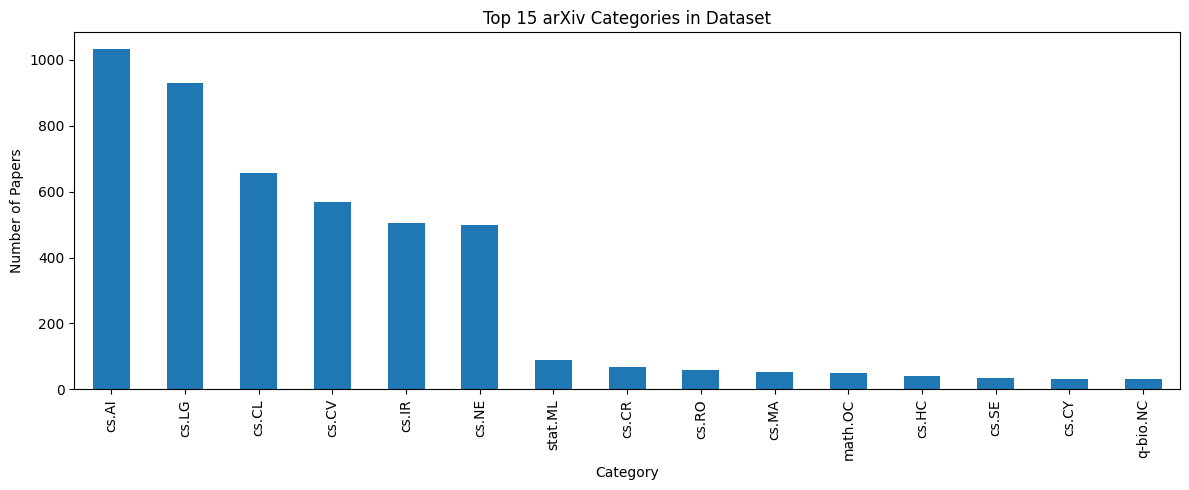

In [57]:
category_counts = df['categories'].explode().value_counts().head(15)
category_counts.plot(kind='bar', figsize=(12,5))
plt.title('Top 15 arXiv Categories in Dataset')
plt.xlabel('Category')
plt.ylabel('Number of Papers')
plt.tight_layout()

## Top Authors by Paper Count

Text(0.5, 1.0, 'Top 20 Most Prolific Authors')

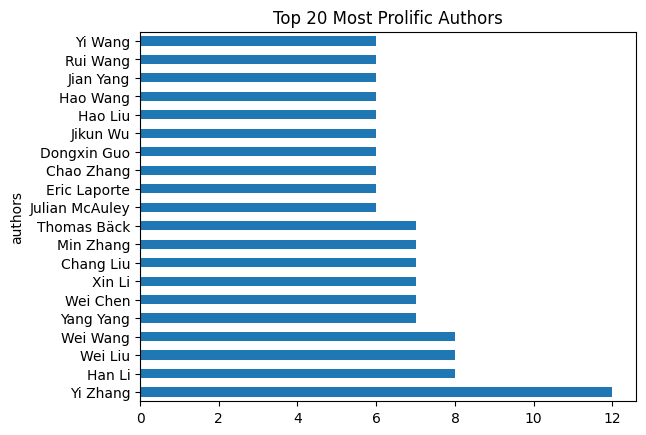

In [58]:
author_counts = df['authors'].explode().value_counts().head(20)
author_counts.plot(kind='barh')
plt.title('Top 20 Most Prolific Authors')

## Average Authors per Paper

Text(0.5, 1.0, 'Distribution of Authors per Paper')

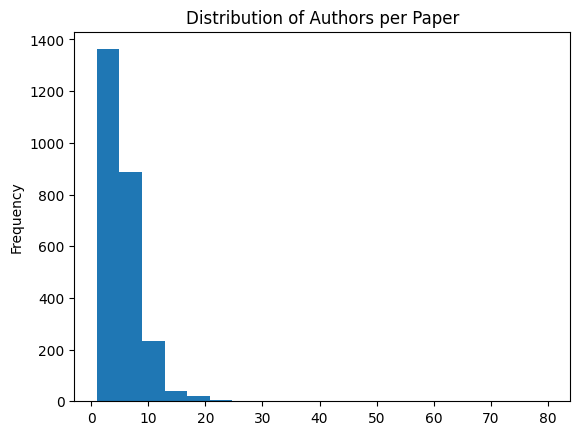

In [59]:
df['author_count'] = df['authors'].apply(len)
df['author_count'].describe()
# histogram
df['author_count'].plot(kind='hist', bins=20)
plt.title('Distribution of Authors per Paper')

## Word Cloud from Titles

Text(0.5, 1.0, 'Most Common Words in Paper Titles')

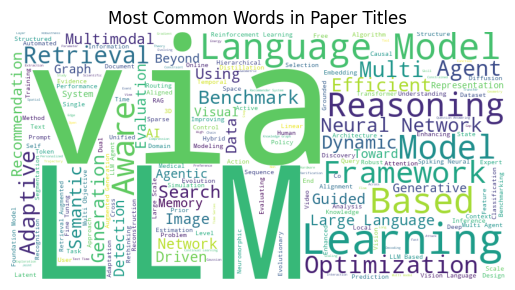

In [60]:
all_titles = ' '.join(df['title'].tolist())
wc = WordCloud(width=800, height=400, background_color='white').generate(all_titles)
plt.imshow(wc)
plt.axis('off')
plt.title('Most Common Words in Paper Titles')

## Abstract Length Distribution

Text(0.5, 1.0, 'Abstract Word Count Distribution')

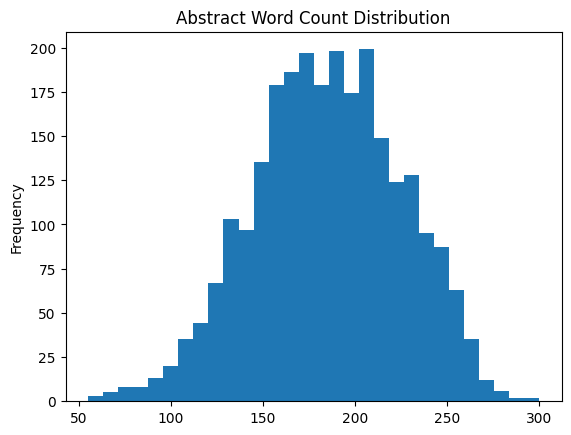

In [61]:
df['abstract_length'] = df['abstract'].apply(lambda x: len(x.split()))
df['abstract_length'].plot(kind='hist', bins=30)
plt.title('Abstract Word Count Distribution')

## Cleaning pipeline

In [62]:
df.isnull().sum()

arxiv_id           0
title              0
abstract           0
authors            0
categories         0
published          0
updated            0
url                0
pdf_url            0
author_count       0
abstract_length    0
dtype: int64

In [63]:
def clean_text(text):
    if not text:
        return ""
    
    # Fix encoding issues
    text = text.encode('utf-8', 'ignore').decode('utf-8')
    
    # Remove LaTeX math expressions  
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [64]:
def extract_keywords_tfidf(texts, top_n=10):
    """
    Takes a list of cleaned abstracts.
    Returns a list of keyword lists — one per document.
    """
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2)
    )
 
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
 
    keywords_per_doc = []
    for row in tfidf_matrix:
        scores = zip(feature_names, np.asarray(row.todense()).flatten())
        sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        top_keywords = [word for word, score in sorted_scores[:top_n] if score > 0]
        keywords_per_doc.append(top_keywords)
 
    return keywords_per_doc

## Cleaning the unecessary infos from Abstract and Title

In [68]:
df['cleaned_abstract'] = df['abstract'].apply(clean_text)
df['cleaned_title'] = df['title'].apply(clean_text)

df['keywords'] = extract_keywords_tfidf(df['cleaned_abstract'].tolist())

df = df.drop(columns=['published', 'updated', 'author_count', 'abstract_length'])

In [69]:
df

,arxiv_id,title,abstract,authors,categories,url,pdf_url,cleaned_abstract,cleaned_title,keywords
0,2605.10938v1,ELF: Embedded Language Flows,Diffusion and flow-based models have become th...,"[Keya Hu, Linlu Qiu, Yiyang Lu, Hanhong Zhao, ...","[cs.CL, cs.AI, cs.LG]",http://arxiv.org/abs/2605.10938v1,https://arxiv.org/pdf/2605.10938v1,Diffusion and flow-based models have become th...,ELF: Embedded Language Flows,"[continuous, discrete, diffusion, embedding sp..."
1,2605.10934v1,Variational Inference for Lévy Process-Driven ...,Modelling extreme events and heavy-tailed phen...,"[Yaman Kindap, Manfred Opper, Benjamin Dupuis,...","[cs.LG, cs.AI, cs.CV, cs.RO, stat.ML]",http://arxiv.org/abs/2605.10934v1,https://arxiv.org/pdf/2605.10934v1,Modelling extreme events and heavy-tailed phen...,Variational Inference for Lévy Process-Driven ...,"[variational, inference, gaussian, carlo, mont..."
2,2605.10933v1,DECO: Sparse Mixture-of-Experts with Dense-Com...,While Mixture-of-Experts (MoE) scales model ca...,"[Chenyang Song, Weilin Zhao, Xu Han, Chaojun X...","[cs.LG, cs.CL]",http://arxiv.org/abs/2605.10933v1,https://arxiv.org/pdf/2605.10933v1,While Mixture-of-Experts (MoE) scales model ca...,DECO: Sparse Mixture-of-Experts with Dense-Com...,"[moe, experts, routed, relu, dense, storage, t..."
3,2605.10931v1,Quantifying Concentration Phenomena of Mean-Fi...,Transformers with self-attention modules as th...,"[Albert Alcalde, Leon Bungert, Konstantin Ried...","[math.AP, cs.LG, math.DS]",http://arxiv.org/abs/2605.10931v1,https://arxiv.org/pdf/2605.10931v1,Transformers with self-attention modules as th...,Quantifying Concentration Phenomena of Mean-Fi...,"[distribution, wasserstein, equation, temperat..."
4,2605.10923v1,Dynamic Skill Lifecycle Management for Agentic...,Large language model agents increasingly rely ...,"[Junhao Shen, Teng Zhang, Xiaoyan Zhao, Hong C...","[cs.LG, cs.CL]",http://arxiv.org/abs/2605.10923v1,https://arxiv.org/pdf/2605.10923v1,Large language model agents increasingly rely ...,Dynamic Skill Lifecycle Management for Agentic...,"[skill, skills, external, policy, active, cont..."
...,...,...,...,...,...,...,...,...,...,...
2548,2602.02724v1,Automatic Design of Optimization Test Problems...,The development of black-box optimization algo...,"[Wojciech Achtelik, Hubert Guzowski, Maciej Sm...",[cs.NE],http://arxiv.org/abs/2602.02724v1,https://arxiv.org/pdf/2602.02724v1,The development of black-box optimization algo...,Automatic Design of Optimization Test Problems...,"[functions, landscapes, landscape, 24, black b..."
2549,2602.02439v1,Energy-Efficient Neuromorphic Computing for Ed...,Edge AI applications increasingly require ultr...,"[Olaf Yunus Laitinen Imanov, Derya Umut Kulali...","[cs.NE, cs.ET, cs.LG]",http://arxiv.org/abs/2602.02439v1,https://arxiv.org/pdf/2602.02439v1,Edge AI applications increasingly require ultr...,Energy-Efficient Neuromorphic Computing for Ed...,"[hardware, edge, hardware aware, energy, spike..."
2550,2602.02311v1,Introns and Templates Matter: Rethinking Linka...,GP-GOMEA is among the state-of-the-art for sym...,"[Johannes Koch, Tanja Alderliesten, Peter A. N...",[cs.NE],http://arxiv.org/abs/2602.02311v1,https://arxiv.org/pdf/2602.02311v1,GP-GOMEA is among the state-of-the-art for sym...,Introns and Templates Matter: Rethinking Linka...,"[gp, template, mutual information, mutual, sym..."
2551,2602.02306v3,Spark: Modular Spiking Neural Networks,"Nowadays, neural networks act as a synonym for...","[Mario Franco, Carlos Gershenson]","[cs.NE, cs.AI, cs.LG]",http://arxiv.org/abs/2602.02306v3,https://arxiv.org/pdf/2602.02306v3,"Nowadays, neural networks act as a synonym for...",Spark: Modular Spiking Neural Networks,"[networks, spiking, neural networks, neural, s..."


In [70]:
df['cleaned_abstract'][0]

"Diffusion and flow-based models have become the de facto approaches for generating continuous data, e.g., in domains such as images and videos. Their success has attracted growing interest in applying them to language modeling. Unlike their image-domain counterparts, today's leading diffusion language models (DLMs) primarily operate over discrete tokens. In this paper, we show that continuous DLMs can be made effective with minimal adaptation to the discrete domain. We propose Embedded Language Flows (ELF), a class of diffusion models in continuous embedding space based on continuous-time Flow Matching. Unlike existing DLMs, ELF predominantly stays within the continuous embedding space until the final time step, where it maps to discrete tokens using a shared-weight network. This formulation makes it straightforward to adapt established techniques from image-domain diffusion models, e.g., classifier-free guidance (CFG). Experiments show that ELF substantially outperforms leading discr

In [71]:
df['abstract'][0]

"Diffusion and flow-based models have become the de facto approaches for generating continuous data, e.g., in domains such as images and videos. Their success has attracted growing interest in applying them to language modeling. Unlike their image-domain counterparts, today's leading diffusion language models (DLMs) primarily operate over discrete tokens. In this paper, we show that continuous DLMs can be made effective with minimal adaptation to the discrete domain. We propose Embedded Language Flows (ELF), a class of diffusion models in continuous embedding space based on continuous-time Flow Matching. Unlike existing DLMs, ELF predominantly stays within the continuous embedding space until the final time step, where it maps to discrete tokens using a shared-weight network. This formulation makes it straightforward to adapt established techniques from image-domain diffusion models, e.g., classifier-free guidance (CFG). Experiments show that ELF substantially outperforms leading discr

## Saving the data

In [76]:
df = df.drop(columns=['cleaned_abstract', 'cleaned_title'])

# Save to JSON
df.to_json('../data/processed_papers.json', orient='records', indent=2)

print(f"Saved {len(df)} papers to data/processed/papers.json")
print(f"Columns saved: {df.columns.tolist()}")

Saved 2553 papers to data/processed/papers.json
Columns saved: ['arxiv_id', 'title', 'abstract', 'authors', 'categories', 'url', 'pdf_url', 'keywords']
